# Canada Healthcare Wait Times Analysis (2008–2025)

## Introduction

Healthcare wait times are an important measure of healthcare system performance and patient access to care. This project analyzes wait-time trends for priority medical procedures across Canadian provinces from 2008 to 2025.

The analysis focuses on four procedures:

- Cataract Surgery
- Hip Replacement
- Knee Replacement
- Radiation Therapy

Using median (P50) wait times, 90th percentile (P90) wait times, benchmark achievement rates, and procedure volumes, this project examines long-term changes in wait-time performance, differences across procedures and provinces, and patterns observed before, during, and after the COVID-19 pandemic period.

## Research Questions

This project investigates three main questions:

1. How have wait times for priority medical procedures changed across Canadian provinces from 2008 to 2025?
2. Which procedures show the greatest deterioration or improvement in wait-time performance?
3. How did wait-time patterns differ between the pre-COVID (2008–2019), pandemic (2020–2022), and recovery (2023–2025) periods?

## Setup and Data Loading

The analysis uses Python libraries for data manipulation, visualization, and simple linear trend analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [2]:
file_path = "../data/Raw Data/wait-times-priority-procedures-in-canada-2008-2025-data-tables-en.xlsx"

df = pd.read_excel(
    file_path,
    sheet_name="Table 1",
    header=1,
    usecols="A:H"
)

## Dataset Overview

The dataset contains Canadian wait-time information for priority medical procedures from 2008 to 2025.

Key variables used in this analysis include:

- **Data year:** Reporting year
- **Province:** Province or territory associated with the observation
- **Indicator:** Medical procedure being measured
- **Metric:** Type of wait-time measure reported
- **Indicator result:** Reported value for the selected metric
- **Unit of measurement:** Days, proportion, or number of cases

The analysis focuses on provincial-level observations for Cataract Surgery, Hip Replacement, Knee Replacement, and Radiation Therapy.

Three main performance measures are examined:

- **P50 (50th percentile):** The median wait time
- **P90 (90th percentile):** The wait time within which 90% of reported cases were completed
- **Percentage meeting benchmark:** The proportion of cases completed within the recommended benchmark

In [3]:
df.shape

(20509, 8)

In [4]:
df.head()

,Reporting level,Province,Region,Indicator,Metric,Data year,Unit of measurement,Indicator result
0,Provincial,Alberta,NaN,Bladder Cancer Surgery,50th percentile,2008,Days,NaN
1,Provincial,Alberta,NaN,Bladder Cancer Surgery,90th percentile,2008,Days,NaN
2,Provincial,Alberta,NaN,Bladder Cancer Surgery,Volume,2008,Number of cases,NaN
3,Provincial,Alberta,NaN,Breast Cancer Surgery,50th percentile,2008,Days,NaN
4,Provincial,Alberta,NaN,Breast Cancer Surgery,90th percentile,2008,Days,NaN


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20509 entries, 0 to 20508
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Reporting level      20509 non-null  str    
 1   Province             20500 non-null  str    
 2   Region               5576 non-null   str    
 3   Indicator            20500 non-null  str    
 4   Metric               20500 non-null  str    
 5   Data year            20500 non-null  object 
 6   Unit of measurement  20500 non-null  str    
 7   Indicator result     16208 non-null  float64
dtypes: float64(1), object(1), str(6)
memory usage: 1.3+ MB


## Data Preparation

The worksheet contains annual observations as well as non-annual labels and explanatory rows. The data is restricted to valid annual records from 2008 to 2025, then filtered to provincial-level observations and the four procedures used in the analysis.

Missing indicator results are retained as missing values rather than imputed because reporting availability varies across provinces, years, and procedures.

In [6]:
# Convert mixed year labels such as fiscal-year strings to numeric when possible.
df["Data year"] = pd.to_numeric(df["Data year"], errors="coerce")

annual = df[df["Data year"].between(2008, 2025)].copy()
annual["Data year"] = annual["Data year"].astype(int)

# Ensure the analysis value column is numeric while preserving missing values.
annual["Indicator result"] = pd.to_numeric(
    annual["Indicator result"],
    errors="coerce"
)

In [7]:
annual[["Data year", "Indicator", "Province", "Metric", "Indicator result"]].isna().sum()

Data year              0
Indicator              0
Province               0
Metric                 0
Indicator result    3748
dtype: int64

In [8]:
annual.duplicated().sum()

np.int64(0)

In [9]:
provincial = annual[
    annual["Reporting level"] == "Provincial"
].copy()

selected_procedures = [
    "Cataract Surgery",
    "Hip Replacement",
    "Knee Replacement",
    "Radiation Therapy"
]

analysis_data = provincial[
    provincial["Indicator"].isin(selected_procedures)
].copy()

## Data Coverage

The final analysis uses annual provincial observations for the four selected procedures. Counts below summarize the available coverage after filtering.

In [10]:
coverage_summary = pd.Series({
    "First year": analysis_data["Data year"].min(),
    "Last year": analysis_data["Data year"].max(),
    "Provinces represented": analysis_data["Province"].nunique(),
    "Procedures": analysis_data["Indicator"].nunique(),
    "Observations": len(analysis_data)
})

coverage_summary

First year               2008
Last year                2025
Provinces represented      10
Procedures                  4
Observations             2880
dtype: int64

# Research Question 1 — How Have Wait Times Changed?

To examine long-term trends, annual averages are calculated across available provincial observations for P50 wait times, P90 wait times, and benchmark achievement. These are descriptive provincial averages and should not be interpreted as official national estimates.

## Analysis-Ready Procedure Tables

In [11]:
procedure_p50_table = (
    analysis_data[analysis_data["Metric"] == "50th percentile"]
    .groupby(["Data year", "Indicator"])["Indicator result"]
    .mean()
    .unstack()
)

procedure_p90_table = (
    analysis_data[analysis_data["Metric"] == "90th percentile"]
    .groupby(["Data year", "Indicator"])["Indicator result"]
    .mean()
    .unstack()
)

procedure_benchmark_table = (
    analysis_data[analysis_data["Metric"] == "% meeting benchmark"]
    .groupby(["Data year", "Indicator"])["Indicator result"]
    .mean()
    .unstack()
)

## P50 Wait-Time Trends

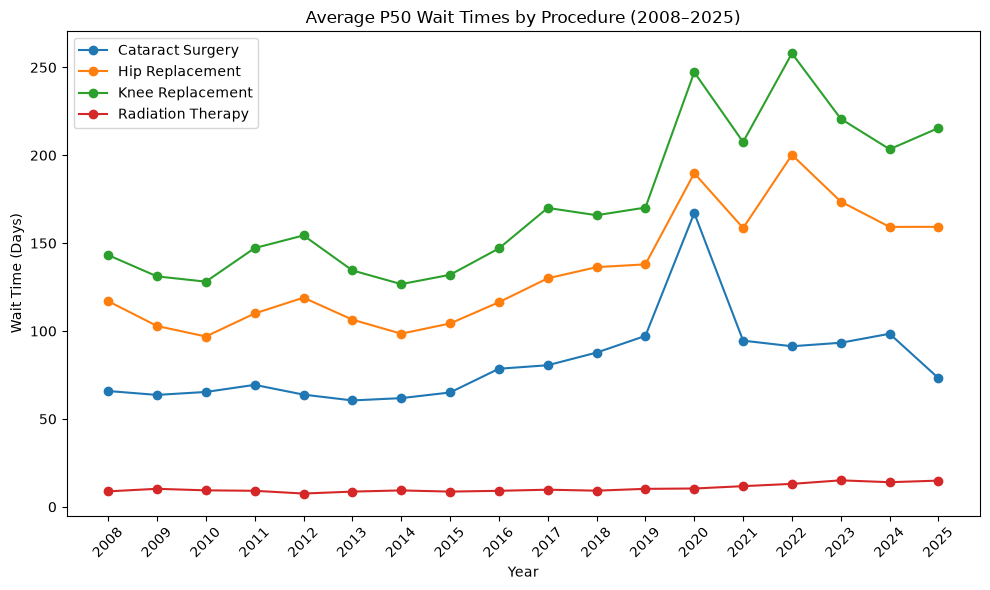

In [12]:
plt.figure(figsize=(10, 6))

for procedure in procedure_p50_table.columns:
    plt.plot(
        procedure_p50_table.index,
        procedure_p50_table[procedure],
        marker="o",
        label=procedure
    )

plt.title("Average P50 Wait Times by Procedure (2008–2025)")
plt.xlabel("Year")
plt.ylabel("Wait Time (Days)")
plt.legend()
plt.xticks(procedure_p50_table.index, rotation=45)
plt.tight_layout()
plt.show()

## P90 Wait-Time Trends

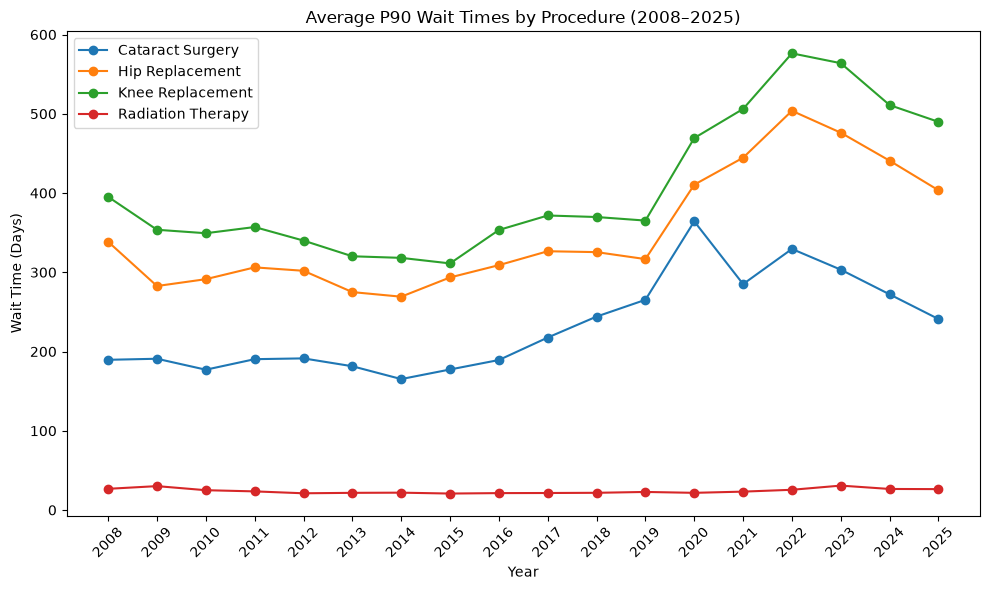

In [13]:
plt.figure(figsize=(10, 6))

for procedure in procedure_p90_table.columns:
    plt.plot(
        procedure_p90_table.index,
        procedure_p90_table[procedure],
        marker="o",
        label=procedure
    )

plt.title("Average P90 Wait Times by Procedure (2008–2025)")
plt.xlabel("Year")
plt.ylabel("Wait Time (Days)")
plt.legend()
plt.xticks(procedure_p90_table.index, rotation=45)
plt.tight_layout()
plt.show()

## Benchmark Achievement Trends

For P50 and P90, lower values indicate shorter waits. For benchmark achievement, higher values indicate better performance.

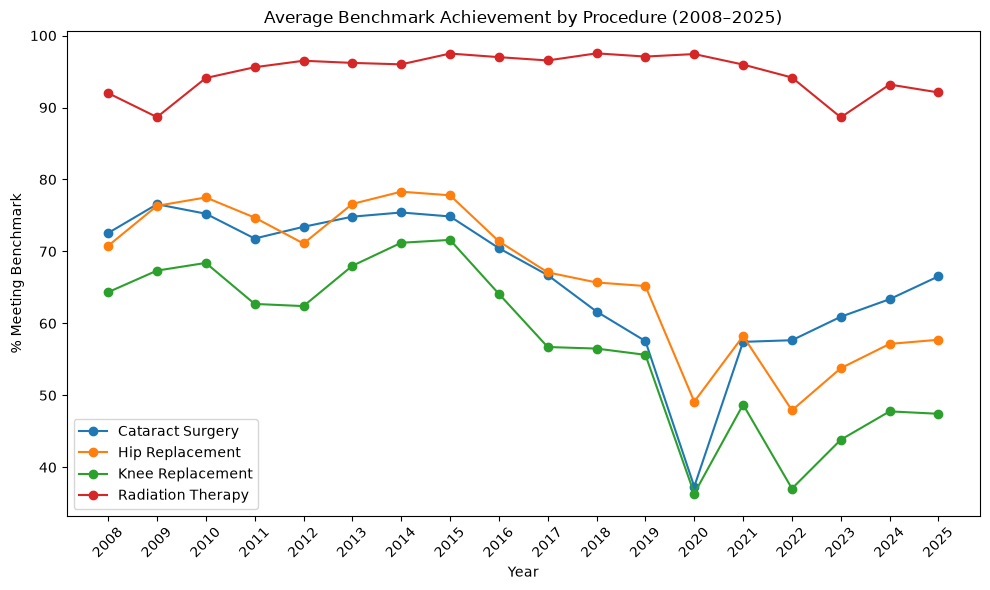

In [14]:
plt.figure(figsize=(10, 6))

for procedure in procedure_benchmark_table.columns:
    plt.plot(
        procedure_benchmark_table.index,
        procedure_benchmark_table[procedure],
        marker="o",
        label=procedure
    )

plt.title("Average Benchmark Achievement by Procedure (2008–2025)")
plt.xlabel("Year")
plt.ylabel("% Meeting Benchmark")
plt.legend()
plt.xticks(procedure_benchmark_table.index, rotation=45)
plt.tight_layout()
plt.show()

# Research Question 2 — Which Procedures Changed the Most?

The 2008 and 2025 endpoints are compared to quantify long-term change. P50 and P90 changes are reported as relative percentages, while benchmark changes are reported in percentage points because the benchmark measure is already a percentage.

In [15]:
p50_change = (
    (procedure_p50_table.loc[2025] - procedure_p50_table.loc[2008])
    / procedure_p50_table.loc[2008]
    * 100
)

p90_change = (
    (procedure_p90_table.loc[2025] - procedure_p90_table.loc[2008])
    / procedure_p90_table.loc[2008]
    * 100
)

benchmark_change = (
    procedure_benchmark_table.loc[2025]
    - procedure_benchmark_table.loc[2008]
)

change_summary = pd.DataFrame({
    "P50 Change (%)": p50_change,
    "P90 Change (%)": p90_change,
    "Benchmark Change (pp)": benchmark_change
}).round(2)

change_summary

,P50 Change (%),P90 Change (%),Benchmark Change (pp)
Indicator,,,
Cataract Surgery,11.10,27.14,-6.02
Hip Replacement,36.15,19.18,-13.06
Knee Replacement,50.47,23.94,-16.90
Radiation Therapy,69.44,-1.47,0.09


## Knee Replacement Deep Dive

Knee Replacement stands out as one of the procedures with the largest deterioration in wait-time performance, so it is examined in more detail.

In [16]:
knee_p50_trend = procedure_p50_table["Knee Replacement"]
knee_p90_trend = procedure_p90_table["Knee Replacement"]
knee_benchmark_trend = procedure_benchmark_table["Knee Replacement"]

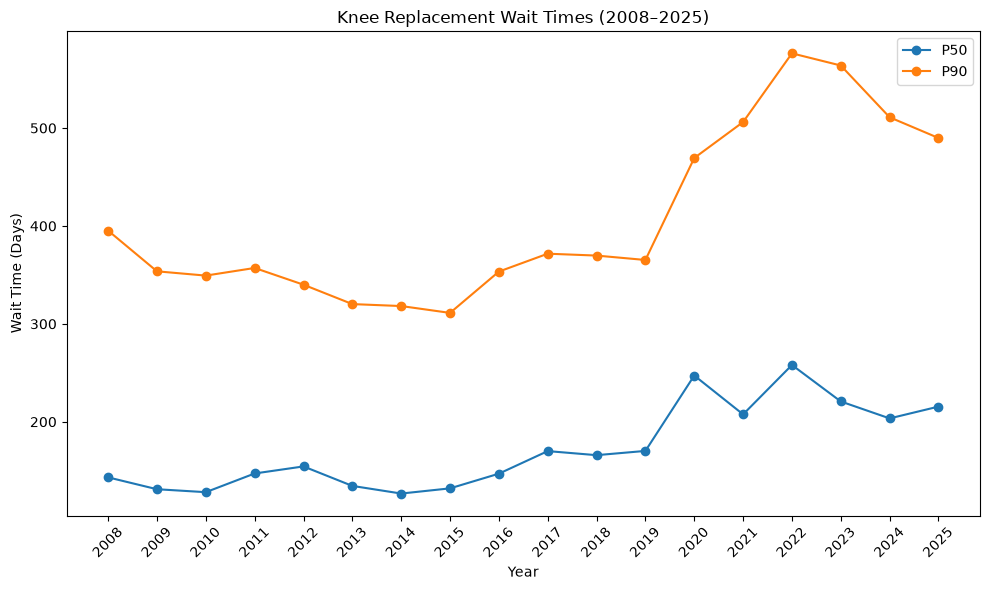

In [17]:
plt.figure(figsize=(10, 6))

plt.plot(
    knee_p50_trend.index,
    knee_p50_trend.values,
    marker="o",
    label="P50"
)

plt.plot(
    knee_p90_trend.index,
    knee_p90_trend.values,
    marker="o",
    label="P90"
)

plt.title("Knee Replacement Wait Times (2008–2025)")
plt.xlabel("Year")
plt.ylabel("Wait Time (Days)")
plt.legend()
plt.xticks(knee_p50_trend.index, rotation=45)
plt.tight_layout()
plt.show()

### P90–P50 Gap

The difference between P90 and P50 provides a simple view of how far the longer-wait end of the distribution sits above the median.

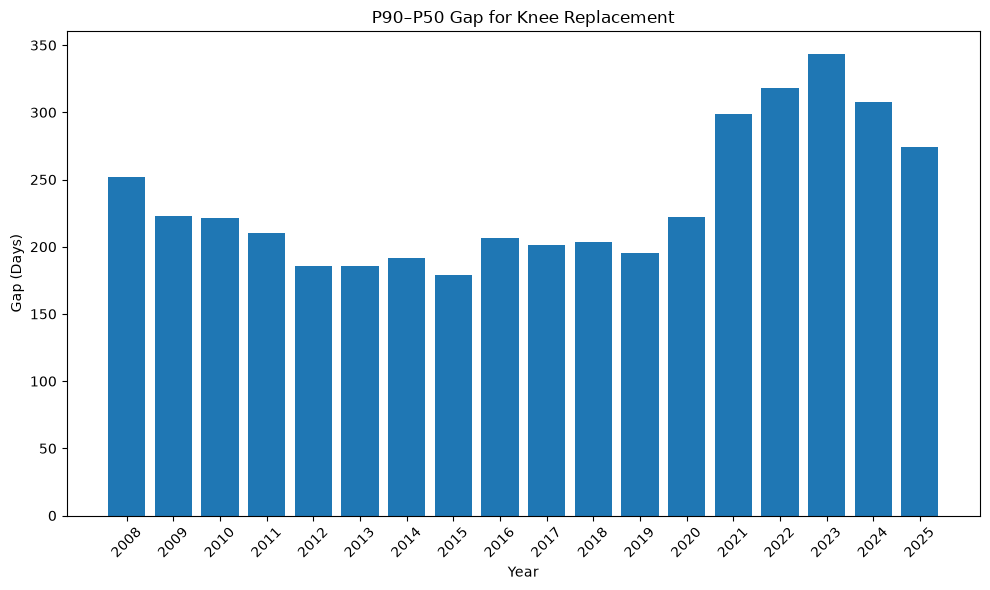

In [18]:
knee_percentile_gap = knee_p90_trend - knee_p50_trend

plt.figure(figsize=(10, 6))
plt.bar(
    knee_percentile_gap.index,
    knee_percentile_gap.values
)

plt.title("P90–P50 Gap for Knee Replacement")
plt.xlabel("Year")
plt.ylabel("Gap (Days)")
plt.xticks(knee_percentile_gap.index, rotation=45)
plt.tight_layout()
plt.show()

### Provincial Comparison

Average provincial P50 and P90 values are used to compare the long-term P90–P50 gap across provinces. Because reporting availability differs by province and year, these values are descriptive rather than fully standardized cross-provincial estimates.

In [19]:
knee_data = analysis_data[
    analysis_data["Indicator"] == "Knee Replacement"
].copy()

province_p50 = (
    knee_data[knee_data["Metric"] == "50th percentile"]
    .groupby("Province")["Indicator result"]
    .mean()
)

province_p90 = (
    knee_data[knee_data["Metric"] == "90th percentile"]
    .groupby("Province")["Indicator result"]
    .mean()
)

province_gap = (province_p90 - province_p50).dropna().sort_values()

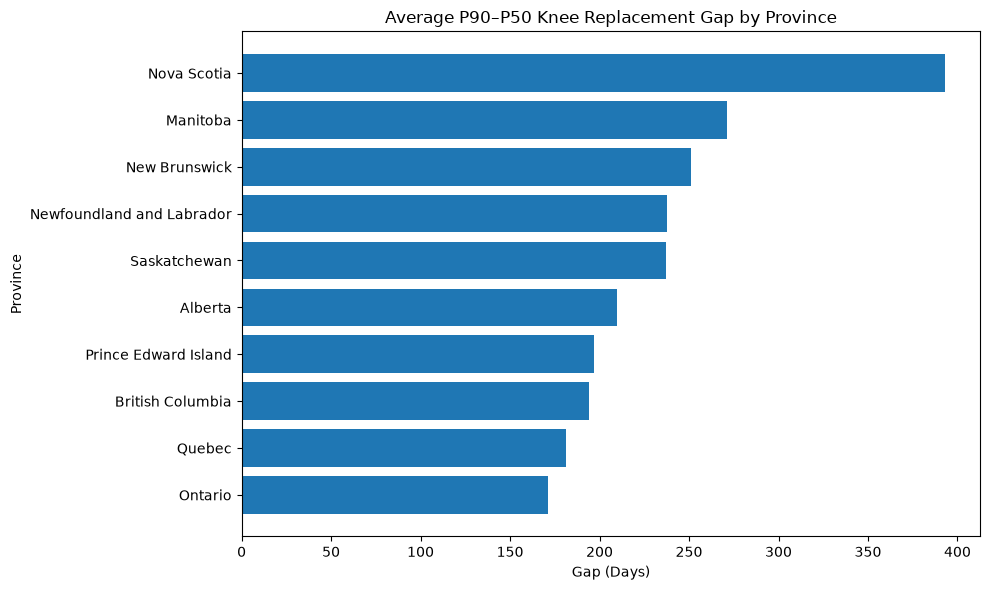

In [20]:
plt.figure(figsize=(10, 6))
plt.barh(
    province_gap.index,
    province_gap.values
)

plt.title("Average P90–P50 Knee Replacement Gap by Province")
plt.xlabel("Gap (Days)")
plt.ylabel("Province")
plt.tight_layout()
plt.show()

### Volume Context

Reported procedure volume is examined as context for changes in wait-time performance.

In [21]:
knee_volume = knee_data[
    knee_data["Metric"] == "Volume"
].copy()

volume_trend = (
    knee_volume
    .groupby("Data year")["Indicator result"]
    .sum()
)

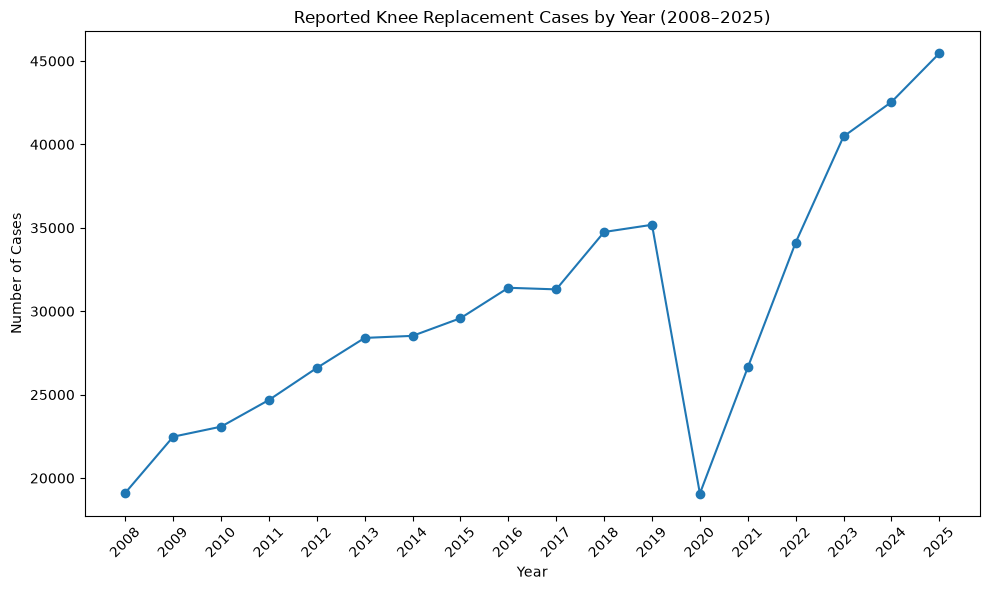

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(
    volume_trend.index,
    volume_trend.values,
    marker="o"
)

plt.title("Reported Knee Replacement Cases by Year (2008–2025)")
plt.xlabel("Year")
plt.ylabel("Number of Cases")
plt.xticks(volume_trend.index, rotation=45)
plt.tight_layout()
plt.show()

### Sensitivity Check: Weighted vs. Unweighted Benchmark

The main benchmark trend uses an unweighted mean across available provincial observations. As a sensitivity check, benchmark performance is also weighted by reported procedure volume where both benchmark and volume are available for the same province and year.

In [23]:
knee_benchmark_data = knee_data[
    knee_data["Metric"] == "% meeting benchmark"
][["Province", "Data year", "Indicator result"]].rename(
    columns={"Indicator result": "Benchmark"}
)

knee_volume_data = knee_data[
    knee_data["Metric"] == "Volume"
][["Province", "Data year", "Indicator result"]].rename(
    columns={"Indicator result": "Volume"}
)

benchmark_volume = pd.merge(
    knee_benchmark_data,
    knee_volume_data,
    on=["Province", "Data year"],
    how="inner"
).dropna(subset=["Benchmark", "Volume"])

benchmark_volume["Weighted Benchmark"] = (
    benchmark_volume["Benchmark"] * benchmark_volume["Volume"]
)

weighted_benchmark_trend = (
    benchmark_volume.groupby("Data year")["Weighted Benchmark"].sum()
    / benchmark_volume.groupby("Data year")["Volume"].sum()
)

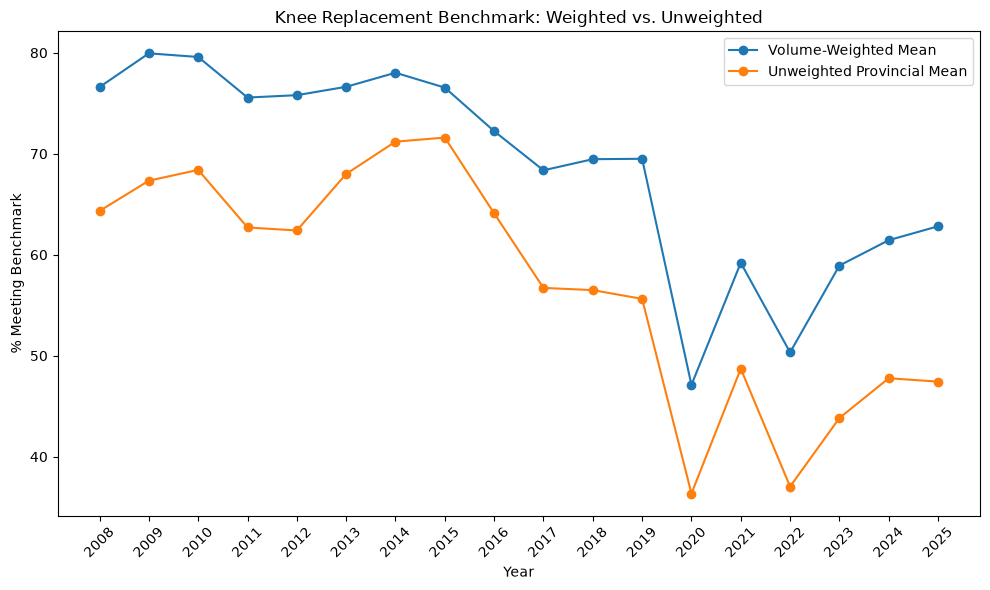

In [24]:
plt.figure(figsize=(10, 6))

plt.plot(
    weighted_benchmark_trend.index,
    weighted_benchmark_trend.values,
    marker="o",
    label="Volume-Weighted Mean"
)

plt.plot(
    knee_benchmark_trend.index,
    knee_benchmark_trend.values,
    marker="o",
    label="Unweighted Provincial Mean"
)

plt.title("Knee Replacement Benchmark: Weighted vs. Unweighted")
plt.xlabel("Year")
plt.ylabel("% Meeting Benchmark")
plt.legend()
plt.xticks(knee_benchmark_trend.index, rotation=45)
plt.tight_layout()
plt.show()

# Research Question 3 — COVID-19 Period Comparison

The study period is divided into three descriptive periods:

- **Pre-COVID:** 2008–2019
- **Pandemic:** 2020–2022
- **Recovery:** 2023–2025

The term **recovery** is used only as a period label and does not imply that wait-time performance returned to pre-pandemic levels. The periods also contain different numbers of years, so comparisons are descriptive.

In [25]:
def assign_period(year):
    if year <= 2019:
        return "Pre-COVID"
    elif year <= 2022:
        return "Pandemic"
    else:
        return "Recovery"

period_order = ["Pre-COVID", "Pandemic", "Recovery"]

## P50 Period Comparison

In [26]:
p50_period = procedure_p50_table.copy()
p50_period["Period"] = p50_period.index.map(assign_period)

p50_period_avg = (
    p50_period
    .groupby("Period")
    .mean()
    .loc[period_order]
)

p50_period_avg.round(2)

Indicator,Cataract Surgery,Hip Replacement,Knee Replacement,Radiation Therapy
Period,,,,
Pre-COVID,71.64,114.65,145.87,9.17
Pandemic,117.68,182.89,237.60,11.75
Recovery,88.33,164.06,213.23,14.66


In [27]:
p50_period_change = pd.DataFrame({
    "Pandemic vs Pre-COVID (%)": (
        (p50_period_avg.loc["Pandemic"] - p50_period_avg.loc["Pre-COVID"])
        / p50_period_avg.loc["Pre-COVID"]
        * 100
    ),
    "Recovery vs Pre-COVID (%)": (
        (p50_period_avg.loc["Recovery"] - p50_period_avg.loc["Pre-COVID"])
        / p50_period_avg.loc["Pre-COVID"]
        * 100
    ),
    "Recovery vs Pandemic (%)": (
        (p50_period_avg.loc["Recovery"] - p50_period_avg.loc["Pandemic"])
        / p50_period_avg.loc["Pandemic"]
        * 100
    )
}).round(2)

p50_period_change

,Pandemic vs Pre-COVID (%),Recovery vs Pre-COVID (%),Recovery vs Pandemic (%)
Indicator,,,
Cataract Surgery,64.27,23.30,-24.94
Hip Replacement,59.52,43.10,-10.29
Knee Replacement,62.88,46.18,-10.26
Radiation Therapy,28.10,59.89,24.81


## P90 Period Comparison

In [28]:
p90_period = procedure_p90_table.copy()
p90_period["Period"] = p90_period.index.map(assign_period)

p90_period_avg = (
    p90_period
    .groupby("Period")
    .mean()
    .loc[period_order]
)

p90_period_avg.round(2)

Indicator,Cataract Surgery,Hip Replacement,Knee Replacement,Radiation Therapy
Period,,,,
Pre-COVID,198.29,303.00,350.41,23.18
Pandemic,326.26,452.98,517.28,23.47
Recovery,272.15,440.14,521.57,27.90


In [29]:
p90_period_change = pd.DataFrame({
    "Pandemic vs Pre-COVID (%)": (
        (p90_period_avg.loc["Pandemic"] - p90_period_avg.loc["Pre-COVID"])
        / p90_period_avg.loc["Pre-COVID"]
        * 100
    ),
    "Recovery vs Pre-COVID (%)": (
        (p90_period_avg.loc["Recovery"] - p90_period_avg.loc["Pre-COVID"])
        / p90_period_avg.loc["Pre-COVID"]
        * 100
    ),
    "Recovery vs Pandemic (%)": (
        (p90_period_avg.loc["Recovery"] - p90_period_avg.loc["Pandemic"])
        / p90_period_avg.loc["Pandemic"]
        * 100
    )
}).round(2)

p90_period_change

,Pandemic vs Pre-COVID (%),Recovery vs Pre-COVID (%),Recovery vs Pandemic (%)
Indicator,,,
Cataract Surgery,64.53,37.24,-16.59
Hip Replacement,49.50,45.26,-2.83
Knee Replacement,47.62,48.84,0.83
Radiation Therapy,1.26,20.38,18.89


## Benchmark Period Comparison

Benchmark changes are shown in **percentage points (pp)** rather than relative percentages.

In [30]:
benchmark_period = procedure_benchmark_table.copy()
benchmark_period["Period"] = benchmark_period.index.map(assign_period)

benchmark_period_avg = (
    benchmark_period
    .groupby("Period")
    .mean()
    .loc[period_order]
)

benchmark_period_avg.round(2)

Indicator,Cataract Surgery,Hip Replacement,Knee Replacement,Radiation Therapy
Period,,,,
Pre-COVID,70.92,72.71,64.08,95.39
Pandemic,50.80,51.76,40.70,95.85
Recovery,63.61,56.21,46.34,91.31


In [31]:
benchmark_period_change = pd.DataFrame({
    "Pandemic vs Pre-COVID (pp)": (
        benchmark_period_avg.loc["Pandemic"]
        - benchmark_period_avg.loc["Pre-COVID"]
    ),
    "Recovery vs Pre-COVID (pp)": (
        benchmark_period_avg.loc["Recovery"]
        - benchmark_period_avg.loc["Pre-COVID"]
    ),
    "Recovery vs Pandemic (pp)": (
        benchmark_period_avg.loc["Recovery"]
        - benchmark_period_avg.loc["Pandemic"]
    )
}).round(2)

benchmark_period_change

,Pandemic vs Pre-COVID (pp),Recovery vs Pre-COVID (pp),Recovery vs Pandemic (pp)
Indicator,,,
Cataract Surgery,-20.12,-7.31,12.81
Hip Replacement,-20.95,-16.49,4.46
Knee Replacement,-23.38,-17.73,5.64
Radiation Therapy,0.46,-4.09,-4.55


# Statistical Trend Analysis

Simple linear regression is used as a descriptive validation of the long-term relationship between year and wait time. The slope represents the fitted average annual change, R² summarizes the strength of the linear fit, and the p-value tests the null hypothesis of a zero linear slope.

These regressions do not establish causation and do not account for more complex time-series structure.

In [32]:
p50_regression_results = {}

for procedure in procedure_p50_table.columns:
    regression_data = procedure_p50_table[procedure].dropna()
    x = regression_data.index.astype(int)
    y = regression_data.values

    result = linregress(x, y)

    p50_regression_results[procedure] = {
        "Slope": result.slope,
        "R-squared": result.rvalue ** 2,
        "P-value": result.pvalue
    }

p50_regression_df = pd.DataFrame(p50_regression_results).T
p50_regression_df.round(4)

,Slope,R-squared,P-value
Cataract Surgery,2.6022,0.3047,0.0176
Hip Replacement,4.9550,0.6745,0.0000
Knee Replacement,6.5499,0.6781,0.0000
Radiation Therapy,0.3451,0.6562,0.0000


In [33]:
p90_regression_results = {}

for procedure in procedure_p90_table.columns:
    regression_data = procedure_p90_table[procedure].dropna()
    x = regression_data.index.astype(int)
    y = regression_data.values

    result = linregress(x, y)

    p90_regression_results[procedure] = {
        "Slope": result.slope,
        "R-squared": result.rvalue ** 2,
        "P-value": result.pvalue
    }

p90_regression_df = pd.DataFrame(p90_regression_results).T
p90_regression_df.round(4)

,Slope,R-squared,P-value
Cataract Surgery,8.3762,0.5688,0.0003
Hip Replacement,10.9763,0.6151,0.0001
Knee Replacement,12.5263,0.5856,0.0002
Radiation Therapy,0.0657,0.0129,0.6538


# Key Findings

1. **Knee Replacement showed the strongest deterioration in median wait time among the four procedures.** From 2008 to 2025, the provincial-average P50 wait time increased by about 50%, while benchmark achievement declined by about 17 percentage points.
2. **Longer-wait cases remained elevated for Knee Replacement.** The P90 trend increased substantially over the study period, and the post-pandemic period showed little improvement in P90 compared with the pandemic-period average.
3. **Cataract, Hip, and Knee procedures deteriorated substantially during the pandemic period.** Their P50 and P90 averages rose and benchmark achievement fell relative to the pre-COVID period.
4. **Knee Replacement showed only partial post-pandemic improvement.** Median wait time and benchmark achievement improved during 2023–2025, but P90 wait time remained approximately at the pandemic-period level.
5. **Radiation Therapy followed a different pattern.** Its P90 wait time showed no statistically significant linear trend from 2008 to 2025, unlike Cataract, Hip, and Knee procedures.

# Limitations

- Provincial reporting availability varies across procedures and years.
- Provincial averages are calculated using available observations and should not be interpreted as official national estimates.
- Unweighted provincial averages give each reporting province equal influence regardless of procedure volume.
- The pre-COVID, pandemic, and recovery periods contain different numbers of years.
- The label **recovery** refers to 2023–2025 and does not imply that wait times fully returned to pre-pandemic levels.
- Linear regression summarizes long-term temporal trends but does not establish causation.
- The analysis does not control for population growth, healthcare capacity, demographic changes, case mix, or changes in provincial reporting practices.

# Conclusion

Across the four priority procedures examined, wait-time performance generally worsened over the 2008–2025 period, with Knee Replacement showing the clearest combination of rising median and long-wait times and declining benchmark performance. The pandemic period coincided with a sharp deterioration in several procedures, and the post-pandemic period shows an uneven recovery rather than a uniform return to earlier performance levels.

The analysis also demonstrates why multiple wait-time measures matter. P50 describes the typical patient experience, P90 captures the longer-wait end of the distribution, and benchmark achievement provides a service-performance perspective. Together, these measures provide a more complete picture than any single indicator alone.